In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
store = pd.read_csv('/content/drive/MyDrive/store.csv')
train = pd.read_csv('/content/drive/MyDrive/train.csv')


In [5]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [7]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [9]:
df = train.merge(store , on = 'Store', how = 'left') 

In [10]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [12]:
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


# Removing Closed Stores

In [13]:
df = df[(df['Open']==1) & (df['Sales']>0)]

In [14]:
df['CompetitionDistance'].fillna(df['CompetitionDistance'].median() , inplace= True)

In [15]:
df['HasCompetition'] = df['CompetitionOpenSinceYear'].notnull().astype(int)
df['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
df['CompetitionOpenSinceYear'].fillna(0, inplace=True)

In [16]:

df.fillna({'Promo2SinceWeek' :0,
           'Promo2SinceYear' : 0 } , inplace= True)


In [17]:
df['PromoInterval'] =df['PromoInterval'].fillna('None')

In [18]:
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      844338 non-null  int64  
 1   DayOfWeek                  844338 non-null  int64  
 2   Date                       844338 non-null  object 
 3   Sales                      844338 non-null  int64  
 4   Customers                  844338 non-null  int64  
 5   Open                       844338 non-null  int64  
 6   Promo                      844338 non-null  int64  
 7   StateHoliday               844338 non-null  object 
 8   SchoolHoliday              844338 non-null  int64  
 9   StoreType                  844338 non-null  object 
 10  Assortment                 844338 non-null  object 
 11  CompetitionDistance        844338 non-null  float64
 12  CompetitionOpenSinceMonth  844338 non-null  float64
 13  CompetitionOpenSinceYear   844338

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      844338 non-null  int64  
 1   DayOfWeek                  844338 non-null  int64  
 2   Date                       844338 non-null  object 
 3   Sales                      844338 non-null  int64  
 4   Customers                  844338 non-null  int64  
 5   Open                       844338 non-null  int64  
 6   Promo                      844338 non-null  int64  
 7   StateHoliday               844338 non-null  object 
 8   SchoolHoliday              844338 non-null  int64  
 9   StoreType                  844338 non-null  object 
 10  Assortment                 844338 non-null  object 
 11  CompetitionDistance        844338 non-null  float64
 12  CompetitionOpenSinceMonth  844338 non-null  float64
 13  CompetitionOpenSinceYear   844338

In [21]:
from datetime import datetime

In [22]:
df['Date'] = pd.to_datetime(df['Date'])

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844338 non-null  int64         
 1   DayOfWeek                  844338 non-null  int64         
 2   Date                       844338 non-null  datetime64[ns]
 3   Sales                      844338 non-null  int64         
 4   Customers                  844338 non-null  int64         
 5   Open                       844338 non-null  int64         
 6   Promo                      844338 non-null  int64         
 7   StateHoliday               844338 non-null  object        
 8   SchoolHoliday              844338 non-null  int64         
 9   StoreType                  844338 non-null  object        
 10  Assortment                 844338 non-null  object        
 11  CompetitionDistance        844338 non-null  float64     

In [24]:
df['StateHoliday'].value_counts()

,count
StateHoliday,
0,731308
0,112120
a,694
b,145
c,71


In [25]:
df['StateHoliday'] = df['StateHoliday'].replace({0:'0'})

In [26]:
df['IsHoliday'] = (df['StateHoliday']!='0').astype(int)
df['IsHoliday'].value_counts()

,count
IsHoliday,
0,843428
1,910


In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
le = LabelEncoder()
df['StateHoliday']= le.fit_transform(df['StateHoliday'])

In [29]:
df['StateHoliday'].value_counts()

,count
StateHoliday,
0,843428
1,694
2,145
3,71


In [30]:
df = df.sort_values(['Store', 'Date'])
df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,HasCompetition,IsHoliday
1014980,1,3,2013-01-02,5530,668,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,None,1,0
1013865,1,4,2013-01-03,4327,578,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,None,1,0
1012750,1,5,2013-01-04,4486,619,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,None,1,0
1011635,1,6,2013-01-05,4997,635,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,None,1,0
1009405,1,1,2013-01-07,7176,785,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,None,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5574,1115,1,2015-07-27,10712,608,1,1,0,1,d,c,5350.0,0.0,0.0,1,22.0,2012.0,"Mar,Jun,Sept,Dec",0,0
4459,1115,2,2015-07-28,8093,500,1,1,0,1,d,c,5350.0,0.0,0.0,1,22.0,2012.0,"Mar,Jun,Sept,Dec",0,0
3344,1115,3,2015-07-29,7661,473,1,1,0,1,d,c,5350.0,0.0,0.0,1,22.0,2012.0,"Mar,Jun,Sept,Dec",0,0
2229,1115,4,2015-07-30,8405,502,1,1,0,1,d,c,5350.0,0.0,0.0,1,22.0,2012.0,"Mar,Jun,Sept,Dec",0,0


# Feature Engineering 

In [31]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Day']= df['Date'].dt.day
df['Week']= df['Date'].dt.isocalendar().week
df['IsWeekend'] = df['DayOfWeek'].isin([6,7]).astype(int)

In [32]:
df.head()


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,HasCompetition,IsHoliday,Year,Month,Quarter,Day,Week,IsWeekend
1014980,1,3,2013-01-02,5530,668,1,0,0,1,c,...,0.0,None,1,0,2013,1,1,2,1,0
1013865,1,4,2013-01-03,4327,578,1,0,0,1,c,...,0.0,None,1,0,2013,1,1,3,1,0
1012750,1,5,2013-01-04,4486,619,1,0,0,1,c,...,0.0,None,1,0,2013,1,1,4,1,0
1011635,1,6,2013-01-05,4997,635,1,0,0,1,c,...,0.0,None,1,0,2013,1,1,5,1,1
1009405,1,1,2013-01-07,7176,785,1,1,0,1,c,...,0.0,None,1,0,2013,1,1,7,2,0


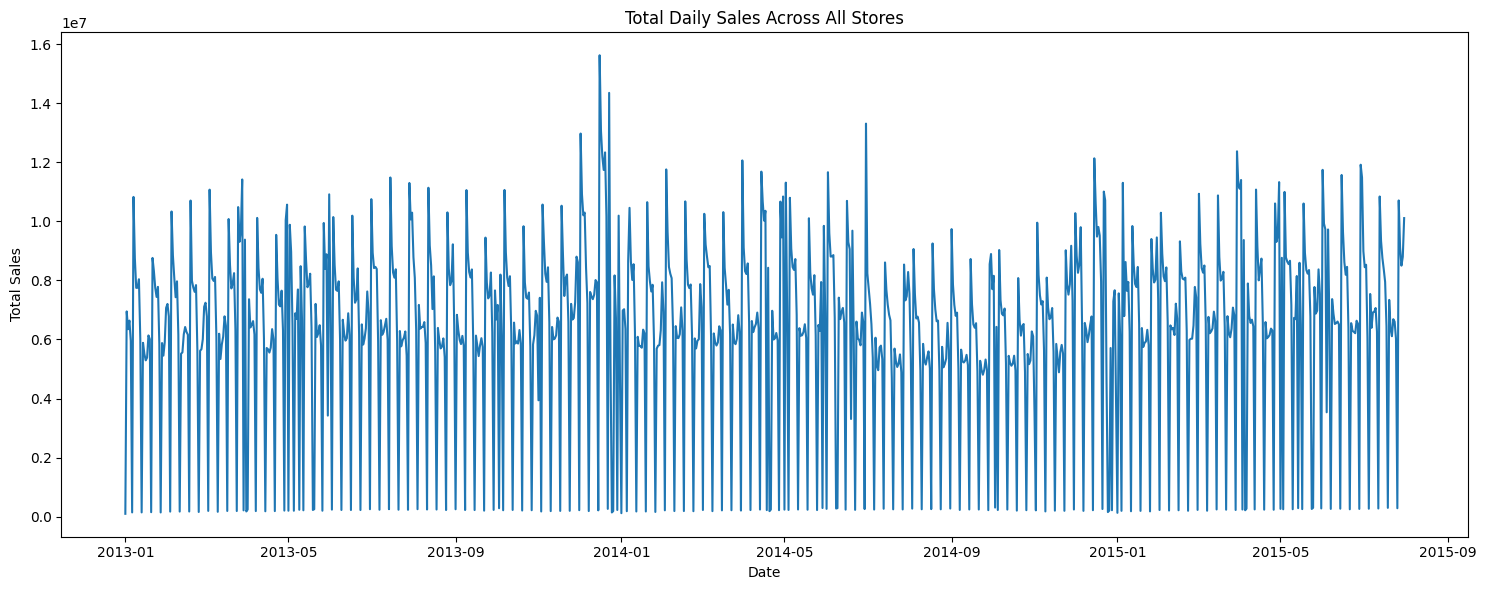

In [33]:

daily_sales = (
    df.groupby('Date')['Sales']
      .sum()
      .reset_index()
)

plt.figure(figsize=(15,6))

sns.lineplot(
    data=daily_sales,
    x='Date',
    y='Sales'
)

plt.title('Total Daily Sales Across All Stores')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

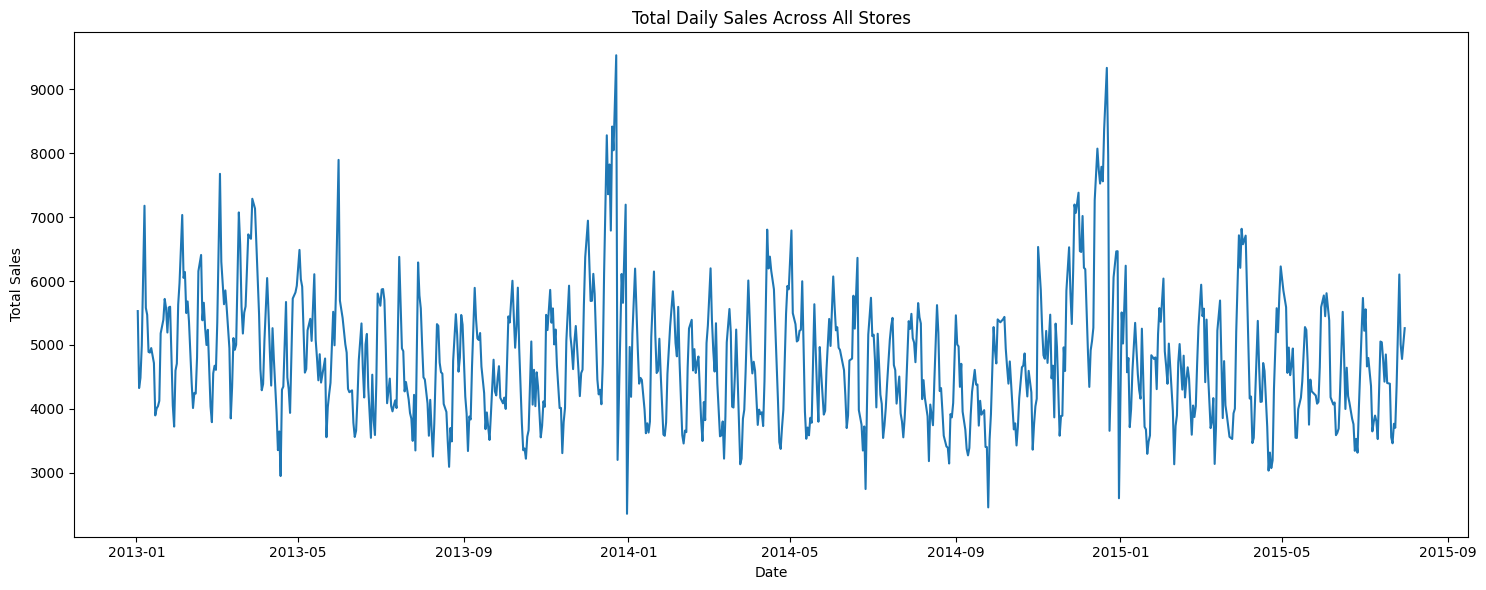

In [34]:
daily_sales = (
    df[df['Store']==1].groupby('Date')['Sales']
      .sum()
      .reset_index()
)

plt.figure(figsize=(15,6))

sns.lineplot(
    data=daily_sales,
    x='Date',
    y='Sales'
)

plt.title('Total Daily Sales Across All Stores')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

In [35]:
yearly_sales  = df.groupby('Year')['Sales'].mean().reset_index()
yearly_sales

,Year,Sales
0,2013,6814.775168
1,2014,7026.128505
2,2015,7088.235123


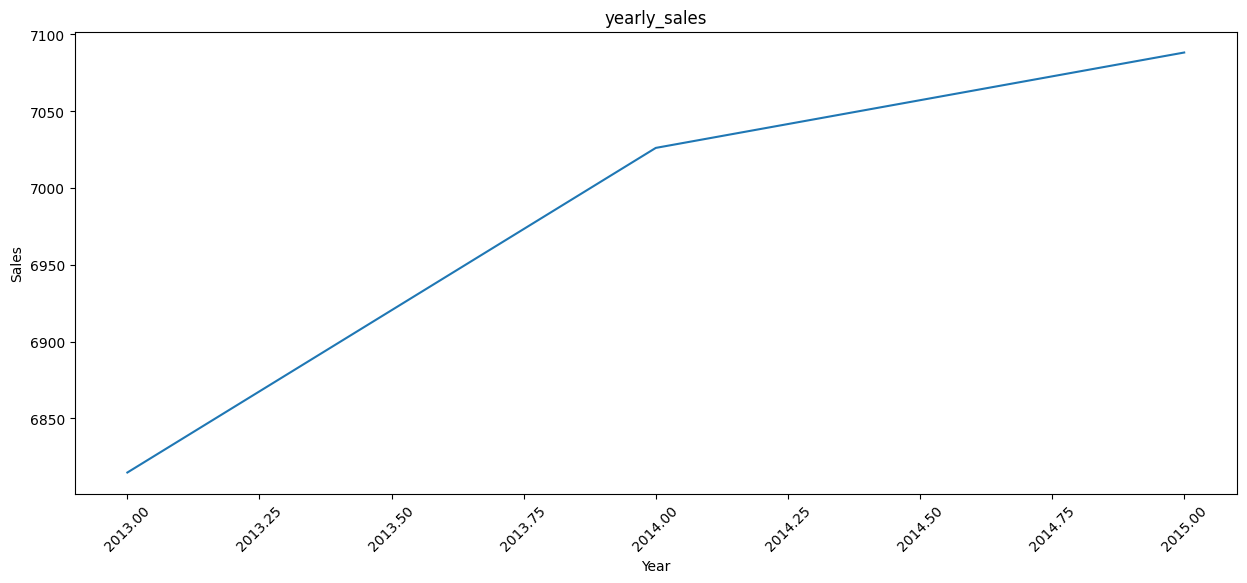

In [36]:
plt.figure(figsize=(15,6))
sns.lineplot(data = yearly_sales , x = 'Year', y = 'Sales' )
plt.xticks(rotation = 45 )
plt.title("yearly_sales")
plt.show()

In [37]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales

,Month,Sales
0,1,566728724
1,2,528734410
2,3,599831906
3,4,575895295
4,5,569248217
5,6,578112775
6,7,595059205
7,8,361791202
8,9,342570131
9,10,351878728


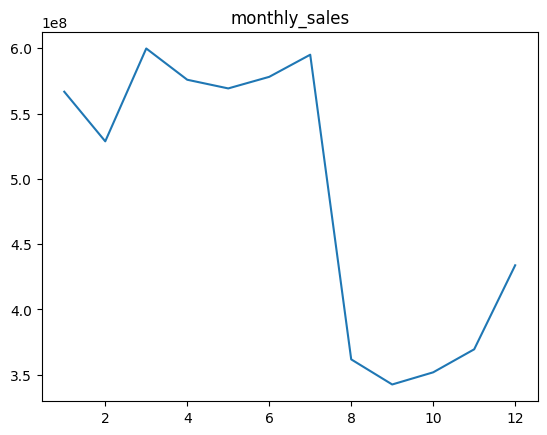

In [38]:
plt.plot(monthly_sales['Month'], monthly_sales['Sales'])
plt.title("monthly_sales")
plt.show()

In [39]:
weekly_sales = df.groupby('DayOfWeek')['Sales'].mean().reset_index()
weekly_sales

,DayOfWeek,Sales
0,1,8216.252259
1,2,7088.409086
2,3,6728.786679
3,4,6768.214973
4,5,7073.034133
5,6,5875.084935
6,7,8224.723908


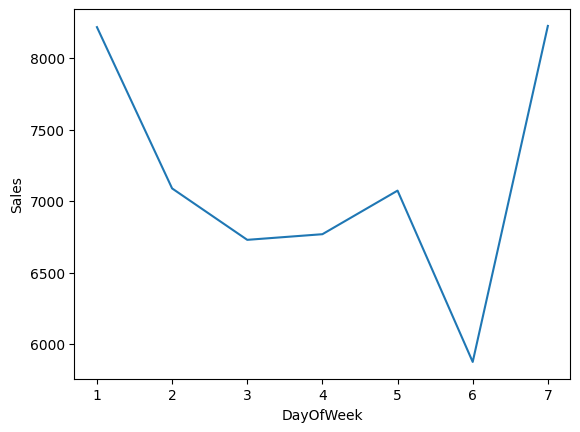

In [40]:
sns.lineplot(weekly_sales , x = 'DayOfWeek' , y= 'Sales')
plt.show()

<Axes: xlabel='Quarter', ylabel='Sales'>

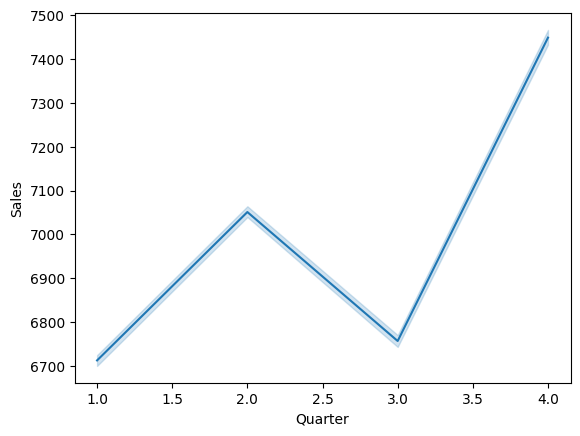

In [41]:
sns.lineplot(df, x = 'Quarter', y = 'Sales')

In [42]:
promo_impact = df.groupby('Promo')['Sales'].mean().reset_index()

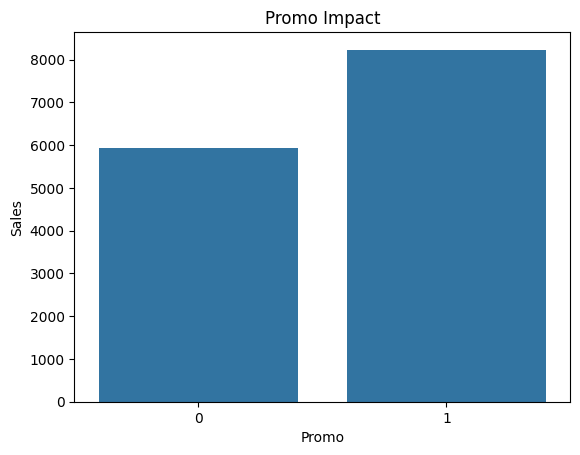

In [43]:
sns.barplot(data = promo_impact , x = 'Promo', y = 'Sales')
plt.title('Promo Impact')
plt.show()

In [44]:
Store_type = df.groupby('StoreType')['Sales'].mean().reset_index()
Store_type

,StoreType,Sales
0,a,6925.697986
1,b,10233.380141
2,c,6933.126425
3,d,6822.300064


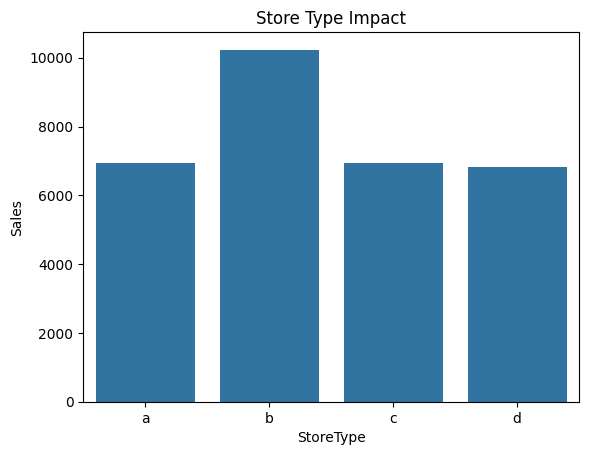

In [45]:
sns.barplot(data = Store_type , x = "StoreType" , y = 'Sales')
plt.title('Store Type Impact')
plt.show()

In [46]:
assortment_effect = df.groupby('Assortment')['Sales'].mean().reset_index()
assortment_effect

,Assortment,Sales
0,a,6621.523057
1,b,8642.503594
2,c,7300.843547


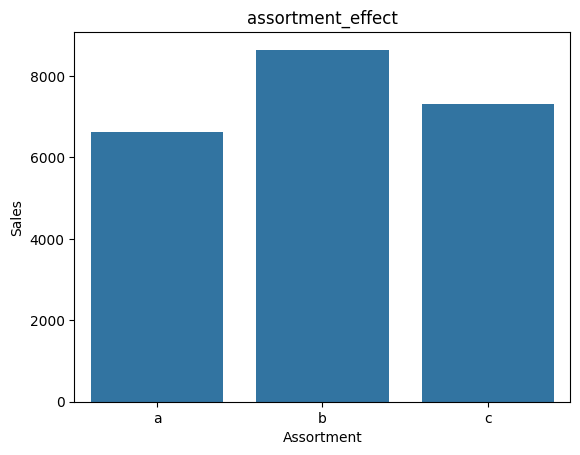

In [47]:
sns.barplot(data = assortment_effect , x = 'Assortment' , y = assortment_effect['Sales'])
plt.title('assortment_effect')
plt.show()

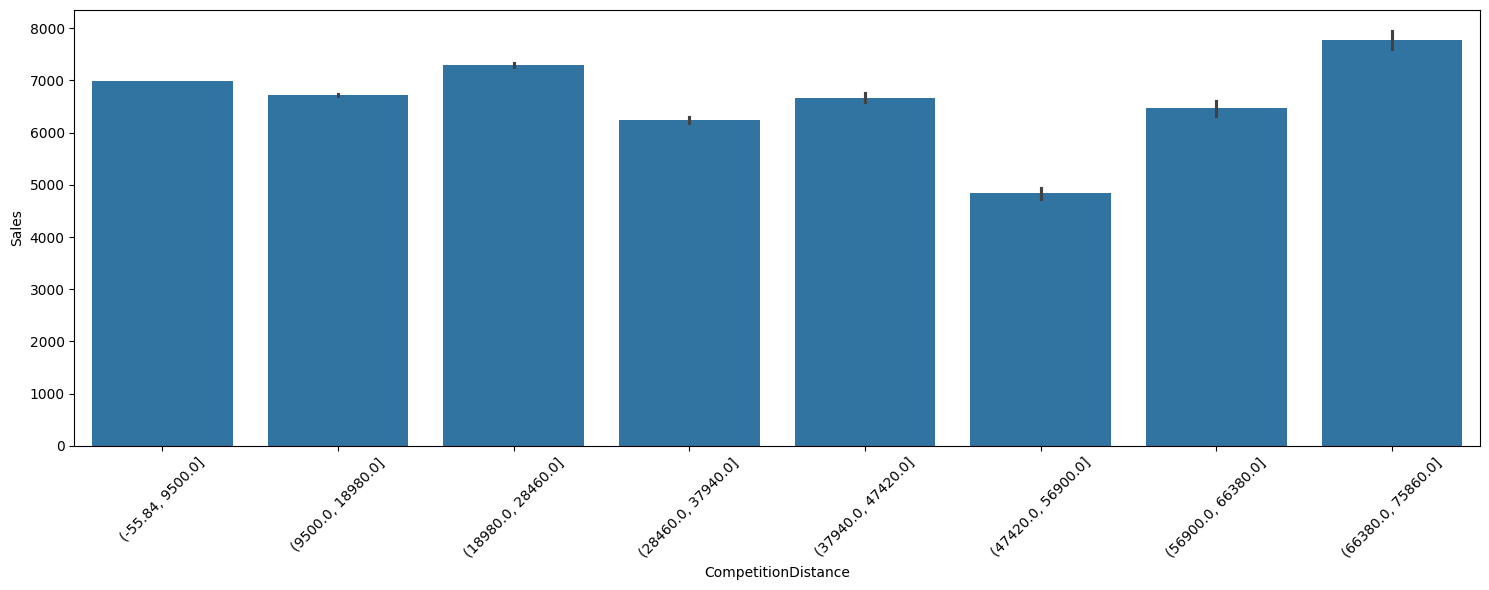

In [48]:

plt.figure(figsize=(15,6))
sns.barplot(data = df , x = pd.cut(df['CompetitionDistance'].round(0), bins =8)
             , y = 'Sales' , estimator=np.mean)
plt.xticks(rotation = 45 )
plt.tight_layout()
plt.show()

In [49]:
state_holiday_effect = df.groupby('StateHoliday')['Sales'].mean().reset_index()

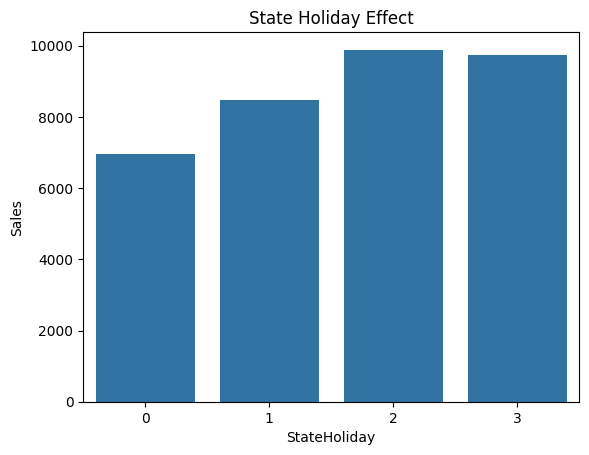

In [50]:
sns.barplot(data = state_holiday_effect , x = 'StateHoliday', y = 'Sales')
plt.title('State Holiday Effect')
plt.show()

In [51]:
school_holiday_effect = df.groupby('SchoolHoliday')['Sales'].mean().reset_index()
school_holiday_effect

,SchoolHoliday,Sales
0,0,6897.207830
1,1,7200.710282


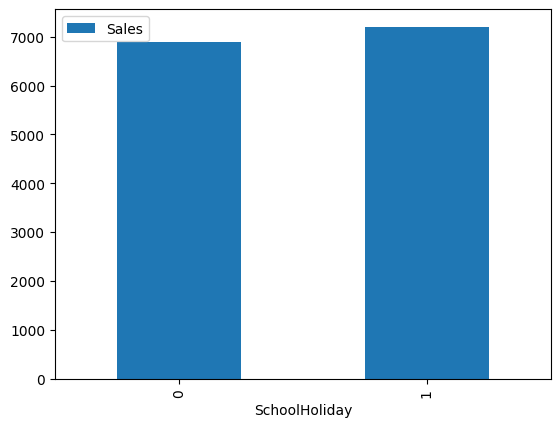

In [52]:
school_holiday_effect.plot(kind= 'bar', x = 'SchoolHoliday'  , y= 'Sales')
plt.show()

# Lag Features

In [53]:
df['lag1']= df.groupby('Store')['Sales'].shift(1)
df['lag7']= df.groupby('Store')['Sales'].shift(7)
df['lag14']= df.groupby('Store')['Sales'].shift(14)
df['lag30']= df.groupby('Store')['Sales'].shift(30)

# Rolling Statistics

In [54]:
df['roll7_mean'] =df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(7).mean())
df['roll30_mean'] =df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(30).mean())

In [55]:
df['StoreType'] = df['StoreType'].astype('category').cat.codes
df['Assortment'] = df['Assortment'].astype('category').cat.codes


In [56]:
df.dropna(inplace=True)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 810888 entries, 975955 to 1114
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      810888 non-null  int64         
 1   DayOfWeek                  810888 non-null  int64         
 2   Date                       810888 non-null  datetime64[ns]
 3   Sales                      810888 non-null  int64         
 4   Customers                  810888 non-null  int64         
 5   Open                       810888 non-null  int64         
 6   Promo                      810888 non-null  int64         
 7   StateHoliday               810888 non-null  int64         
 8   SchoolHoliday              810888 non-null  int64         
 9   StoreType                  810888 non-null  int8          
 10  Assortment                 810888 non-null  int8          
 11  CompetitionDistance        810888 non-null  float64   

In [58]:
df = df.sort_values('Date')

In [59]:
train= df[df['Date']< '2015-06-01']
val = df[df['Date']>='2015-06-01']

In [60]:

ts = train[train['Store']==1].groupby('Date')['Sales'].sum().reset_index()
ts = ts.sort_values('Date')
ts.set_index('Date', inplace=True)

# Check for stationarity

In [61]:
from statsmodels.tsa.stattools import adfuller

res = adfuller(ts)
adf_stat, p_value, usedlag, nobs, crit_vals = res[0], res[1], res[2], res[3], res[4]

print("ADF Statistic:", adf_stat)
print("p-value:", p_value)
print("Used lag:", usedlag)
print("Number of obs:", nobs)
print("Critical Values:", crit_vals)
print("Stationary:" , p_value < 0.05)

ADF Statistic: -5.192266122587634
p-value: 9.11741868514979e-06
Used lag: 13
Number of obs: 685
Critical Values: {'1%': np.float64(-3.4399324443722814), '5%': np.float64(-2.865768564020576), '10%': np.float64(-2.5690218258831052)}
Stationary: True


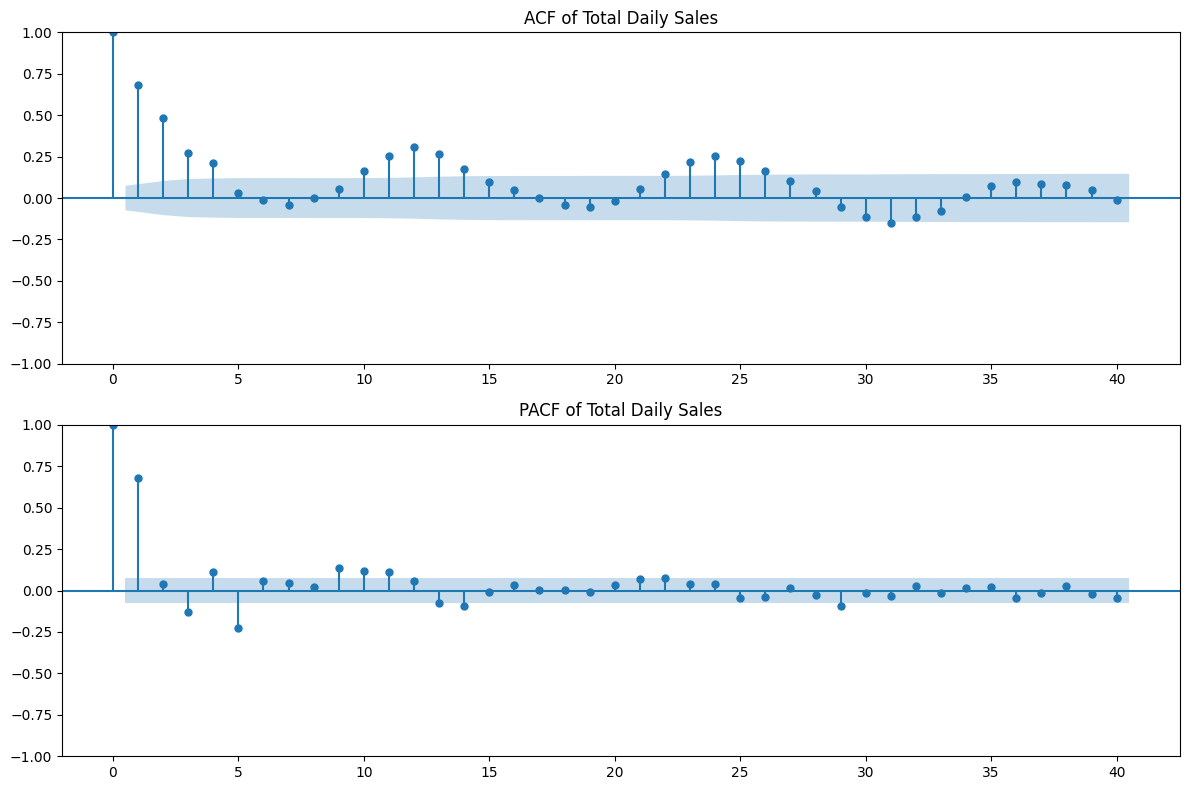

In [62]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf



fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(ts, lags=40, ax=axes[0])
axes[0].set_title('ACF of Total Daily Sales')

plot_pacf(ts, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF of Total Daily Sales')
# 40 lags is chosen to capture about 6 weeks of daily autocorrelation;
#  30 lags would show only about one month and may miss longer weekly/short-term patterns
plt.tight_layout()
plt.show()

# SARIMA MODEL - Store 1

In [63]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [64]:
sarima_model = SARIMAX(ts, order = (2,0,2), seasonal_order= (2,0,2,6) , 
                 enforce_invertibility= False , enforce_stationarity=False)
# chose 202 becuase it gave lowest aic value
results = sarima_model.fit()
print(results.summary())
print("AIC : ",results.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             Sales   No. Observations:                  699
Model:             SARIMAX(2, 0, 2)x(2, 0, 2, 6)   Log Likelihood               -5496.440
Date:                           Thu, 25 Jun 2026   AIC                          11010.880
Time:                                   12:34:26   BIC                          11051.632
Sample:                                        0   HQIC                         11026.650
                                           - 699                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1024      0.060     -1.718      0.086      -0.219       0.014
ar.L2          0.6197      0.063      9.831

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [65]:
val_ts = val[val['Store']==1].groupby('Date')['Sales'].sum().reset_index().sort_values('Date').set_index('Date')
val_ts.head()

,Sales
Date,
2015-06-01,5774
2015-06-02,5450
2015-06-03,5809
2015-06-05,5384
2015-06-06,4183


In [66]:
val_pred = results.forecast(steps = len(val_ts))
val_pred.head()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,predicted_mean
699,5333.822328
700,5459.000120
701,5229.764879
702,5145.443923
703,4768.887736


In [67]:
val_ts.head()

,Sales
Date,
2015-06-01,5774
2015-06-02,5450
2015-06-03,5809
2015-06-05,5384
2015-06-06,4183


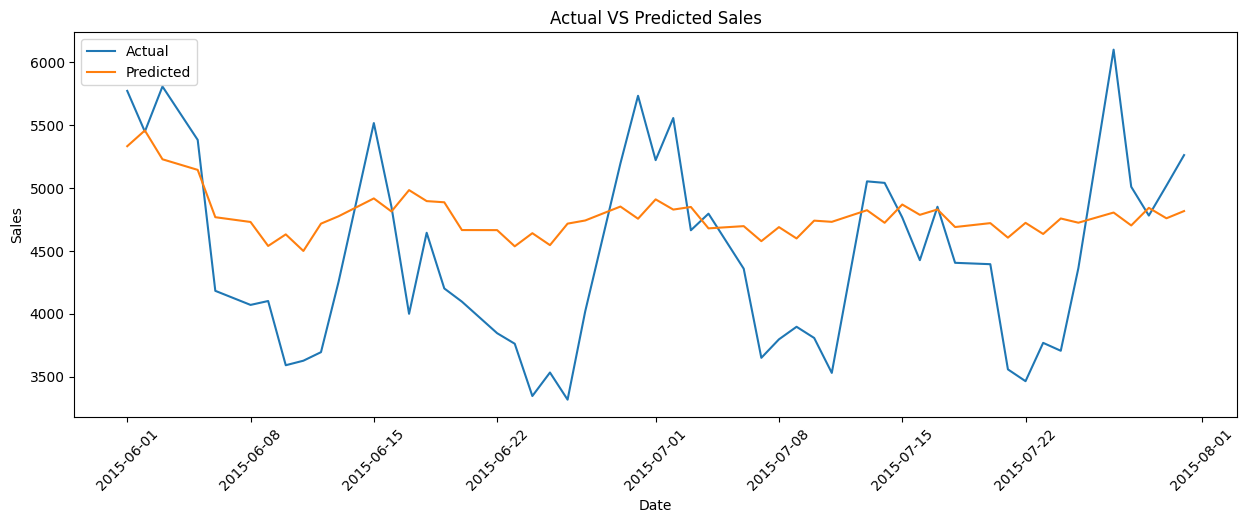

In [68]:
plt.figure(figsize = (15,5))

plt.plot(val_ts.index , val_ts['Sales'] , label = 'Actual')
plt.plot(val_ts.index , val_pred , label = "Predicted")
plt.title('Actual VS Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation =45)
plt.legend()
plt.show()

In [69]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(
    val_ts['Sales'],
    val_pred
)

rmse = np.sqrt(
    mean_squared_error(
        val_ts['Sales'],
        val_pred
    )
)

mape = mean_absolute_percentage_error(
    val_ts['Sales'],
    val_pred
)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape*100:.2f}%")

MAE  : 612.14
RMSE : 719.39
MAPE : 15.06%


# PROPHET

In [70]:
pip install prophet

In [71]:
train.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'HasCompetition', 'IsHoliday',
       'Year', 'Month', 'Quarter', 'Day', 'Week', 'IsWeekend', 'lag1', 'lag7',
       'lag14', 'lag30', 'roll7_mean', 'roll30_mean'],
      dtype='object')

In [72]:
from prophet import Prophet

In [73]:
train_store1 = train[train["Store"] == 1 ][['Date','Sales', 'IsHoliday']].copy()

In [74]:
train_store1.rename(columns={'Date':'ds',
                             'Sales': 'y'}, inplace =True)

In [75]:
train_store1.sort_values('ds', inplace=True)
train_store1['IsHoliday'].value_counts(dropna=False)

,count
IsHoliday,
0,699


In [76]:
train_store1.head()

,ds,y,IsHoliday
975955,2013-02-06,6140,0
974840,2013-02-07,5499,0
973725,2013-02-08,5681,0
972610,2013-02-09,5370,0
970380,2013-02-11,4409,0


In [77]:
model_prophet= Prophet(yearly_seasonality= True,
                       weekly_seasonality=True,
                       daily_seasonality= False)

model_prophet.add_regressor('IsHoliday')

In [78]:
model_prophet.fit(train_store1)

In [79]:
prophet_val = val[val['Store']== 1][['Date', 'Sales', 'IsHoliday']].copy()
prophet_val.sort_values('Date' , inplace = True)

In [80]:
prophet_val.rename(columns= {'Date': 'ds',
                             'Sales': 'y'} , inplace=True)

In [81]:
prophet_val.head()

,ds,y,IsHoliday
66900,2015-06-01,5774,0
65785,2015-06-02,5450,0
64670,2015-06-03,5809,0
62440,2015-06-05,5384,0
61325,2015-06-06,4183,0


In [82]:
future = prophet_val.drop(columns = 'y')

In [83]:
forecast = model_prophet.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,IsHoliday,IsHoliday_lower,IsHoliday_upper,additive_terms,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-06-01,4747.892987,3829.435805,6048.980600,4747.892987,4747.892987,0.0,0.0,0.0,160.166832,...,327.316311,327.316311,327.316311,-167.149479,-167.149479,-167.149479,0.0,0.0,0.0,4908.059818
1,2015-06-02,4747.871208,3381.406772,5560.522535,4747.871208,4747.871208,0.0,0.0,0.0,-319.631856,...,-165.581689,-165.581689,-165.581689,-154.050167,-154.050167,-154.050167,0.0,0.0,0.0,4428.239352
2,2015-06-03,4747.849429,3210.235115,5432.061835,4747.849429,4747.849429,0.0,0.0,0.0,-413.282334,...,-274.142199,-274.142199,-274.142199,-139.140135,-139.140135,-139.140135,0.0,0.0,0.0,4334.567095
3,2015-06-05,4747.805871,3487.955911,5712.016868,4747.805871,4747.805871,0.0,0.0,0.0,-193.795139,...,-87.508183,-87.508183,-87.508183,-106.286957,-106.286957,-106.286957,0.0,0.0,0.0,4554.010731
4,2015-06-06,4747.784092,3723.596425,5835.472245,4747.784092,4747.784092,0.0,0.0,0.0,38.633856,...,128.268205,128.268205,128.268205,-89.634349,-89.634349,-89.634349,0.0,0.0,0.0,4786.417947


In [84]:
comparison = pd.DataFrame({
    'Date': prophet_val['ds'].values,
    'Actual': prophet_val['y'].values,
    'Predicted': forecast['yhat'].values
})

In [85]:
comparison.head()

,Date,Actual,Predicted
0,2015-06-01,5774,4908.059818
1,2015-06-02,5450,4428.239352
2,2015-06-03,5809,4334.567095
3,2015-06-05,5384,4554.010731
4,2015-06-06,4183,4786.417947


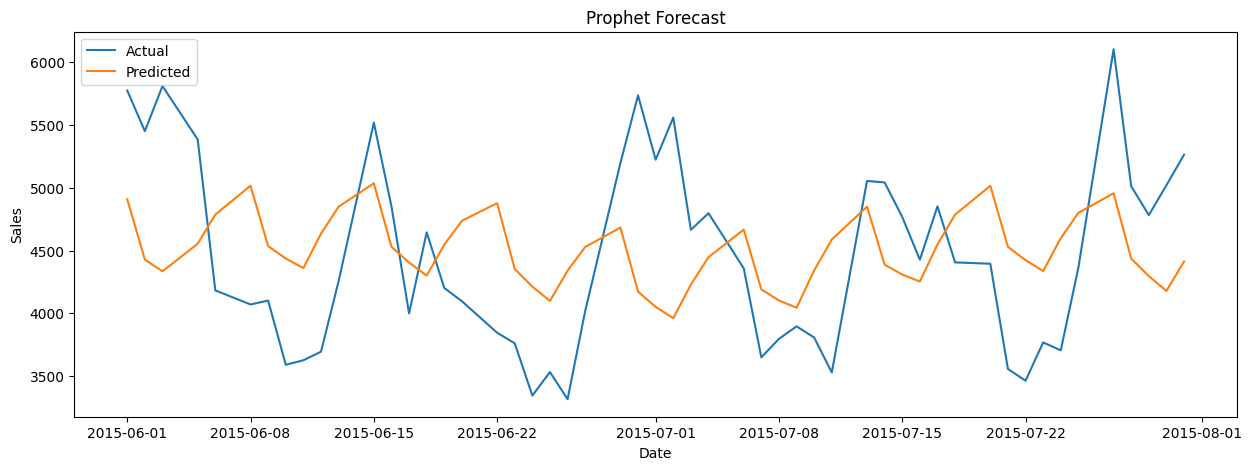

In [86]:
plt.figure(figsize=(15,5))

plt.plot(
    comparison['Date'],
    comparison['Actual'],
    label='Actual'
)

plt.plot(
    comparison['Date'],
    comparison['Predicted'],
    label='Predicted'
)

plt.title('Prophet Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()
plt.show()

In [87]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

mae = mean_absolute_error(
    comparison['Actual'],
    comparison['Predicted']
)

rmse = np.sqrt(
    mean_squared_error(
        comparison['Actual'],
        comparison['Predicted']
    )
)

mape = mean_absolute_percentage_error(
    comparison['Actual'],
    comparison['Predicted']
)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape*100:.2f}%")

MAE  : 681.80
RMSE : 761.87
MAPE : 15.58%


# XGBoost Store 1

In [88]:
X_train1  = train[train['Store']==1].drop(columns= ['Sales', 'PromoInterval', 'StateHoliday','Date' ,'Customers' , 'Open'])
y_train1  =  train[train['Store']==1]['Sales']
X_val1 = val[val['Store']==1].drop(columns = ['Sales', 'PromoInterval', 'StateHoliday','Date' , 'Customers','Open'])
y_val1 = val[val['Store']==1]['Sales']

In [89]:
X_train1.head()

,Store,DayOfWeek,Promo,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,...,Quarter,Day,Week,IsWeekend,lag1,lag7,lag14,lag30,roll7_mean,roll30_mean
975955,1,3,1,0,2,0,1270.0,9.0,2008.0,0,...,1,6,6,0,6049.0,3725.0,5394.0,5530.0,5388.428571,5103.833333
974840,1,4,1,0,2,0,1270.0,9.0,2008.0,0,...,1,7,6,0,6140.0,4601.0,5720.0,4327.0,5733.428571,5124.166667
973725,1,5,1,0,2,0,1270.0,9.0,2008.0,0,...,1,8,6,0,5499.0,4709.0,5578.0,4486.0,5861.714286,5163.233333
972610,1,6,0,0,2,0,1270.0,9.0,2008.0,0,...,1,9,6,1,5681.0,5633.0,5195.0,4997.0,6000.571429,5203.066667
970380,1,1,0,0,2,0,1270.0,9.0,2008.0,0,...,1,11,7,0,5370.0,5970.0,5586.0,7176.0,5963.000000,5215.500000


In [90]:
from xgboost import XGBRegressor


In [91]:
xgb1 = XGBRegressor(  n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1)

In [92]:
xgb1.fit(X_train1, y_train1)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [93]:
xgb_pred1 = xgb1.predict(X_val1)

In [94]:
mae = mean_absolute_error(y_val1 , xgb_pred1)
rmse = np.sqrt(mean_squared_error(y_val1, xgb_pred1))
mape = mean_absolute_percentage_error(y_val1 , xgb_pred1)


In [95]:
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape*100)

MAE : 265.9737243652344
RMSE: 315.76921210355516
MAPE: 6.136779487133026


In [96]:

comparison1 = pd.DataFrame({
    'Actual': y_val1.values ,
    'Predicted': xgb_pred1

})
comparison1 = comparison1.head(100)

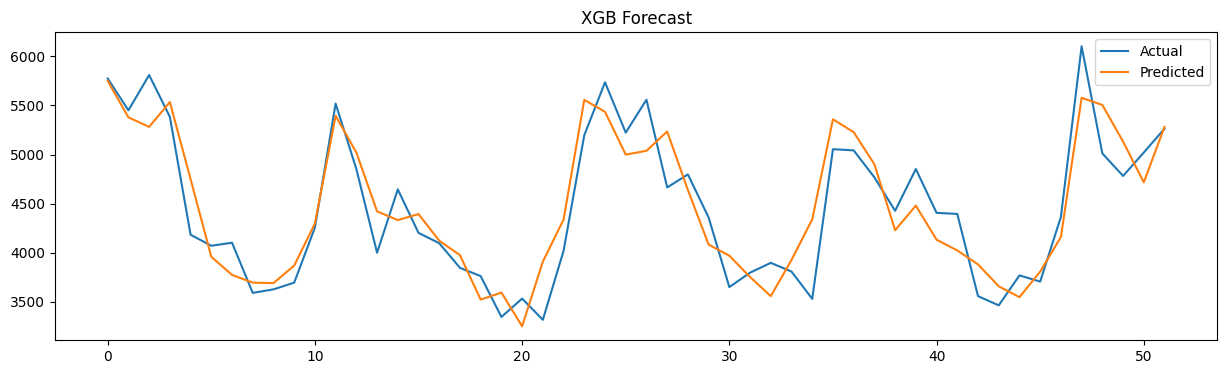

In [97]:
plt.figure(figsize = (15,4))
plt.plot(comparison1['Actual'], label = 'Actual')
plt.plot(comparison1['Predicted'] , label = 'Predicted')
plt.legend()
plt.title('XGB Forecast')
plt.show()

# XGBOOST - Overall

In [98]:
X_train  = train.drop(columns= ['Sales', 'PromoInterval', 'StateHoliday','Date' ,'Customers' , 'Open'])
y_train  =  train['Sales']
X_val = val.drop(columns = ['Sales', 'PromoInterval', 'StateHoliday','Date' , 'Customers','Open'])
y_val = val['Sales']

In [99]:
X_train.head()

,Store,DayOfWeek,Promo,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,...,Quarter,Day,Week,IsWeekend,lag1,lag7,lag14,lag30,roll7_mean,roll30_mean
982979,335,4,0,0,1,0,90.0,0.0,0.0,1,...,1,31,5,0,12944.0,15533.0,11767.0,2401.0,11753.142857,12138.166667
983592,948,4,0,0,1,1,1430.0,0.0,0.0,0,...,1,31,5,0,4313.0,4418.0,4584.0,4491.0,4672.714286,4444.766667
983326,682,4,0,0,1,0,150.0,9.0,2006.0,0,...,1,31,5,0,10809.0,14552.0,11478.0,3375.0,10371.000000,11059.566667
982906,262,4,0,0,1,0,1180.0,5.0,2013.0,0,...,1,31,5,0,16092.0,19255.0,16275.0,17267.0,18099.000000,18235.900000
983377,733,4,0,0,1,1,860.0,10.0,1999.0,0,...,1,31,5,0,13544.0,13472.0,13876.0,10765.0,13513.857143,12940.200000


In [100]:
X_train.columns

Index(['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'StoreType',
       'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'HasCompetition', 'IsHoliday', 'Year', 'Month',
       'Quarter', 'Day', 'Week', 'IsWeekend', 'lag1', 'lag7', 'lag14', 'lag30',
       'roll7_mean', 'roll30_mean'],
      dtype='object')

In [101]:
from xgboost import XGBRegressor


In [102]:
xgb = XGBRegressor(  n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1)

In [103]:
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [104]:
xgb_pred = xgb.predict(X_val)

In [105]:
mae = mean_absolute_error(y_val , xgb_pred)
rmse = np.sqrt(mean_squared_error(y_val, xgb_pred))
mape = mean_absolute_percentage_error(y_val , xgb_pred)


In [106]:
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape*100)

MAE : 629.8676147460938
RMSE: 874.571144904747
MAPE: 9.687943756580353


In [107]:
comparison = pd.DataFrame({
    'Actual': y_val.values ,
    'Predicted': xgb_pred

})
comparison = comparison.head(100)

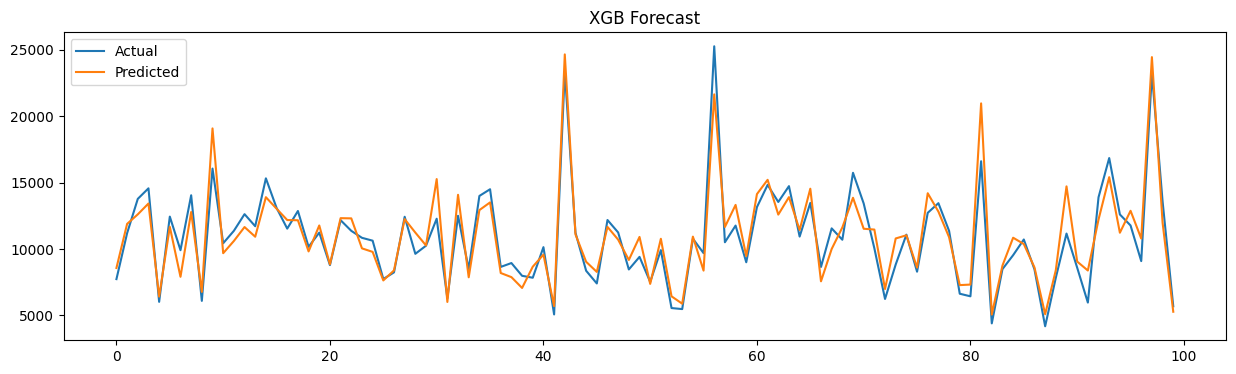

In [108]:
plt.figure(figsize = (15,4))
plt.plot(comparison['Actual'], label = 'Actual')
plt.plot(comparison['Predicted'] , label = 'Predicted')
plt.legend()
plt.title('XGB Forecast')
plt.show()

### Feature Importance 

In [109]:
importance = pd.DataFrame({
    'Feature': X_train.columns ,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values('Importance' , ascending =False)
importance.head(10)

,Feature,Importance
25,roll30_mean,0.316012
2,Promo,0.220578
20,lag1,0.181628
24,roll7_mean,0.042136
1,DayOfWeek,0.041839
22,lag14,0.029746
18,Week,0.017561
17,Day,0.017249
19,IsWeekend,0.015120
21,lag7,0.015038


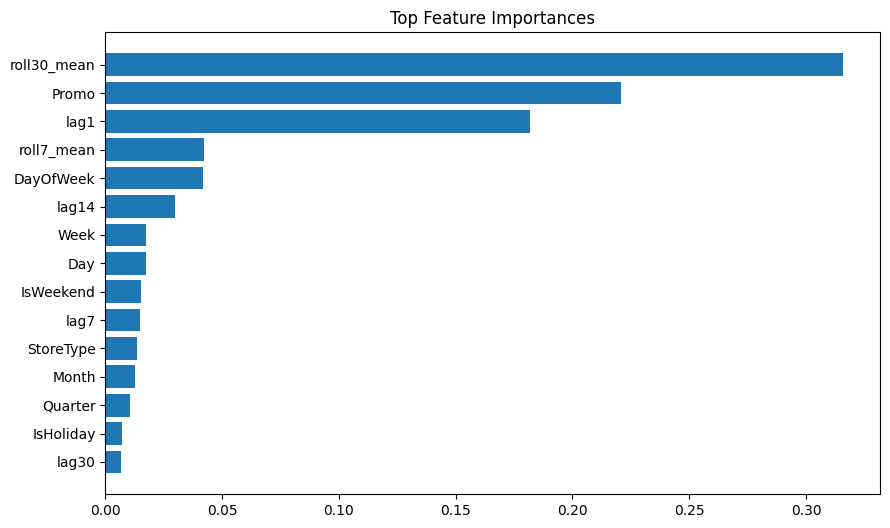

In [110]:
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'].head(15),
    importance['Importance'].head(15)
)

plt.gca().invert_yaxis()

plt.title('Top Feature Importances')
plt.show()

# LSTM

In [111]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

In [112]:
features = ['Sales', 'Promo', 'IsHoliday', 'roll7_mean', 'roll30_mean']

In [113]:
lstm_train = train[train['Store'] == 1][['Date'] + features].sort_values('Date').reset_index(drop=True)
lstm_val   = val[val['Store'] == 1][['Date'] + features].sort_values('Date').reset_index(drop=True)


In [114]:
lstm_train.head()

,Date,Sales,Promo,IsHoliday,roll7_mean,roll30_mean
0,2013-02-06,6140,1,0,5388.428571,5103.833333
1,2013-02-07,5499,1,0,5733.428571,5124.166667
2,2013-02-08,5681,1,0,5861.714286,5163.233333
3,2013-02-09,5370,0,0,6000.571429,5203.066667
4,2013-02-11,4409,0,0,5963.000000,5215.500000


In [115]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(lstm_train[features])
val_scaled   = scaler.transform(lstm_val[features])


In [116]:
WINDOW = 30
# lstm will look for data of last 30 days for prediction

In [117]:
def create_sequences_multivariate(data, window, target_col_idx=0):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, :])
        y.append(data[i, target_col_idx])
    return np.array(X), np.array(y)

X_train_seq, y_train_seq = create_sequences_multivariate(train_scaled, WINDOW)

In [118]:
combined_val_input = np.concatenate([train_scaled[-WINDOW:], val_scaled])
X_val_seq, y_val_seq = create_sequences_multivariate(combined_val_input, WINDOW)

In [119]:
print("X_train_seq:", X_train_seq.shape, "X_val_seq:", X_val_seq.shape)

X_train_seq: (669, 30, 5) X_val_seq: (52, 30, 5)


In [120]:
n_features = len(features)


In [121]:
model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(WINDOW, n_features)),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])

In [122]:
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

In [123]:
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    verbose=1
)

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0300 - val_loss: 0.0118
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0208 - val_loss: 0.0105
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0187 - val_loss: 0.0089
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0174 - val_loss: 0.0089
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0170 - val_loss: 0.0072
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0168 - val_loss: 0.0075
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0155 - val_loss: 0.0065
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0155 - val_loss: 0.0068
Epoch 9/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0141 - val_loss: 0.0062
Epoch 10/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0143 - val_loss: 0.0060
Epoch 11/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0147 - val_loss: 0.0096
Epoch 12/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0

In [124]:
lstm_pred_scaled = model.predict(X_val_seq)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 303ms/step


In [125]:
def inverse_scale_target(scaled_target, scaler, n_features, target_idx=0):
    dummy = np.zeros((len(scaled_target), n_features))
    dummy[:, target_idx] = scaled_target.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

lstm_pred = inverse_scale_target(lstm_pred_scaled, scaler, n_features)
y_val_actual = inverse_scale_target(y_val_seq.reshape(-1,1), scaler, n_features)

In [126]:
mae = mean_absolute_error(y_val_actual, lstm_pred)
rmse = np.sqrt(mean_squared_error(y_val_actual, lstm_pred))
mape = mean_absolute_percentage_error(y_val_actual, lstm_pred)

In [127]:
print(f"LSTM MAE  : {mae:,.2f}")
print(f"LSTM RMSE : {rmse:,.2f}")
print(f"LSTM MAPE : {mape*100:.2f}%")

LSTM MAE  : 351.89
LSTM RMSE : 470.00
LSTM MAPE : 7.86%


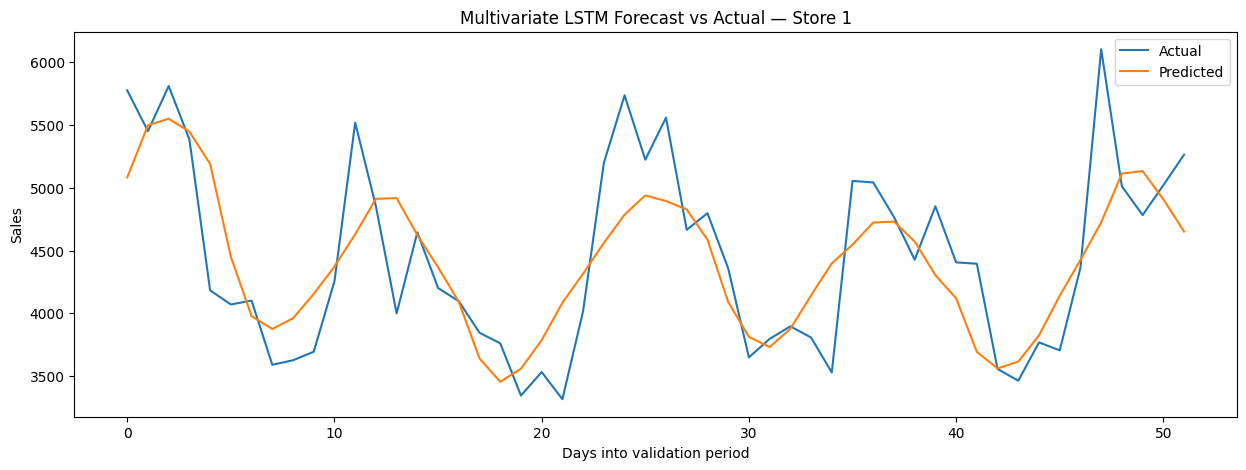

In [128]:
plt.figure(figsize=(15,5))
plt.plot(y_val_actual, label='Actual')
plt.plot(lstm_pred, label='Predicted')
plt.title('Multivariate LSTM Forecast vs Actual — Store 1')
plt.xlabel('Days into validation period')
plt.ylabel('Sales')
plt.legend()
plt.show()


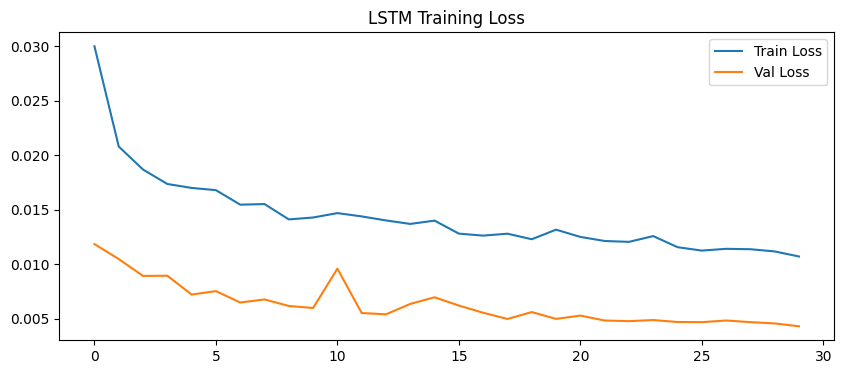

In [129]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training Loss')
plt.legend()
plt.show()

In [130]:
import joblib

# Save the combined-store XGBoost model
joblib.dump(xgb, 'xgb_model.pkl')

# Save actual vs predicted for all stores
val_with_date = val[['Store', 'Date']].copy()
val_with_date['Actual'] = y_val.values
val_with_date['Predicted'] = xgb_pred
val_with_date.to_csv('val_predictions.csv', index=False)

# Save feature importance
importance.to_csv('feature_importance.csv', index=False)

# Save latest feature row per store (for the promo simulator)
latest_rows = X_val.sort_values('Store').groupby('Store').tail(1)
latest_rows.to_csv('latest_store_features.csv', index=False)

print("Done. 4 files saved.")

Done. 4 files saved.


In [131]:
import shutil

shutil.copy('xgb_model.pkl', '/content/drive/MyDrive/xgb_model.pkl')
shutil.copy('val_predictions.csv', '/content/drive/MyDrive/val_predictions.csv')
shutil.copy('feature_importance.csv', '/content/drive/MyDrive/feature_importance.csv')
shutil.copy('latest_store_features.csv', '/content/drive/MyDrive/latest_store_features.csv')

print("Copied to Drive.")

Copied to Drive.


In [132]:
# 1. Load test + merge store info (same as train)
test = pd.read_csv('/content/drive/MyDrive/test.csv')
test = test.merge(store, on='Store', how='left')

# 2. Fix the  null Open values — standard fix, assume store is open
test['Open'] = test['Open'].fillna(1)

# 3. Apply SAME imputations as train — IMPORTANT: use train's saved median, not test's own
competition_median = df['CompetitionDistance'].median()  # from your training df
test['CompetitionDistance'].fillna(competition_median, inplace=True)
test['HasCompetition'] = test['CompetitionOpenSinceYear'].notnull().astype(int)
test['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
test['CompetitionOpenSinceYear'].fillna(0, inplace=True)
test.fillna({'Promo2SinceWeek': 0, 'Promo2SinceYear': 0}, inplace=True)
test['PromoInterval'] = test['PromoInterval'].fillna('None')

# 4. Date conversion + calendar features (same as train)
test['Date'] = pd.to_datetime(test['Date'])
test['Year'] = test['Date'].dt.year
test['Month'] = test['Date'].dt.month
test['Quarter'] = test['Date'].dt.quarter
test['Day'] = test['Date'].dt.day
test['Week'] = test['Date'].dt.isocalendar().week
test['IsWeekend'] = test['DayOfWeek'].isin([6,7]).astype(int)
test['StateHoliday'] = test['StateHoliday'].replace({0:"0"})
test['IsHoliday'] = (test['StateHoliday'] != '0').astype(int)

# 5. CRITICAL: encode StoreType/Assortment using TRAIN'S category mapping, not a fresh one
test['StoreType'] = test['StoreType'].astype(pd.CategoricalDtype(categories=store['StoreType'].unique())).cat.codes
test['Assortment'] = test['Assortment'].astype(pd.CategoricalDtype(categories=store['Assortment'].unique())).cat.codes

# 6. Carry forward last known lag/rolling values per store from train
last_known = df.sort_values('Date').groupby('Store').tail(1)[
    ['Store', 'lag1', 'lag7', 'lag14', 'lag30', 'roll7_mean', 'roll30_mean']
]

test = test.merge(last_known, on='Store', how='left')

# 7. Build final feature set — must match X_train's columns exactly
feature_cols = X_train.columns.tolist()
X_test = test[feature_cols]

# 8. Predict
test['Sales_Predicted'] = xgb.predict(X_test)

# 9. Force closed stores to 0 — Open=0 means no sales, model shouldn't guess
test.loc[test['Open'] == 0, 'Sales_Predicted'] = 0

# 10. Final submission-style output
submission = test[['Id', 'Sales_Predicted']].rename(columns={'Sales_Predicted': 'Sales'})
submission.to_csv('test_predictions.csv', index=False)

In [133]:
test_output = test[['Store', 'Date', 'Sales_Predicted']]
test_output.to_csv('future_predictions.csv', index=False)

In [134]:
import shutil
shutil.copy('future_predictions.csv', '/content/drive/MyDrive/future_predictions.csv')

'/content/drive/MyDrive/future_predictions.csv'

In [135]:
test['Store'].nunique()

856

In [136]:
test.sort_values('Date').tail()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,Week,IsWeekend,IsHoliday,lag1,lag7,lag14,lag30,roll7_mean,roll30_mean,Sales_Predicted
566,567,732,4,2015-09-17,1.0,1,0,0,1,1,...,38,0,0,10812.0,8174.0,8154.0,9262.0,9617.142857,8787.433333,9966.488281
565,566,731,4,2015-09-17,1.0,1,0,0,1,0,...,38,0,0,9700.0,6957.0,11489.0,7660.0,8495.142857,9035.633333,9314.857422
564,565,729,4,2015-09-17,1.0,1,0,0,0,1,...,38,0,0,11337.0,8695.0,11754.0,10403.0,10358.142857,10796.066667,10836.790039
562,563,727,4,2015-09-17,1.0,1,0,0,1,0,...,38,0,0,5357.0,4431.0,5513.0,4816.0,5044.571429,4804.466667,5054.167969
0,1,1,4,2015-09-17,1.0,1,0,0,0,0,...,38,0,0,5020.0,3769.0,4767.0,3317.0,4679.142857,4475.700000,4843.170898
